# Step 4：動力学の局所一次近似とQ関数と局所二次近似

## 概要

iLQRは、非線形動力学モデルを含む最適制御問題を、基準軌道の周りに構成した局所的な線形・二次(LQ)問題として反復的に解く。

そのため、基準軌道の近傍で非線形動力学モデルを一次近似、ステージコストと終端コストを二次近似する。

次に、現在のステージコストと次時刻以降の最小コストを、線形化動力学を介して価値関数とQ関数により結びつける。これより、Q関数を状態摂動$\delta X_n$ と入力摂動 $\delta u_n$ に関する局所二次式として構成する。

backward passでは、この局所二次Q関数を入力修正項$\delta u_n$について最小化し、入力修正項を求める。

## 1. 非線形動力学モデルの局所一次近似

具体的に、非線形バネモデルを対象として、基準軌道の近傍の一次近似を行う。

#### 状態方程式

非線形バネモデルの運動方程式を以下とする。

$$
m \ddot{x} = u - k x - k_3 x^3
$$

状態を $X$ とする。

$$
X = \begin{bmatrix} x \\ v \end{bmatrix} , \quad v = \dot{x}
$$

すると、状態方程式は以下となる。

$$
\dot{X} = \begin{bmatrix} \dot{x} \\ \dot{v} \end{bmatrix} =
\begin{bmatrix}  v \\ \dfrac{1}{m}\left( u - k x - k_3 x^3 \right) \end{bmatrix}
$$

#### 離散時間状態方程式

iLQRが扱うのは離散時間モデルであるため、刻み時間を $\Delta t$ として、前進Euler法で離散化する。

$$
\begin{aligned}
x_{n+1} &= x_n + \Delta t v_n \\
v_{n+1} &= v_n + \dfrac{\Delta t}{m}\left(u_n - k x_n - k_3 x_n^3 \right)
\end{aligned}
$$

状態$X$でまとめると、離散時間状態方程式は以下となる。この式は$x_n^3$があるため非線形である。

$$
\begin{aligned}
X_{n+1} &= f(X_n , u_n) \\
\begin{bmatrix}
x_{n+1} \\
v_{n+1} 
\end{bmatrix} &=
\begin{bmatrix}
x_n + \Delta t v_n \\
v_n + \dfrac{\Delta t}{m}\left(u_n - k x_n - k_3 x_n^3 \right)
\end{bmatrix}
\end{aligned}
$$

#### 基準軌道の近傍点

入力列を使い、上記の離散時間状態方程式をrolloutすると、基準軌道を得ることが出来る。

$$
\begin{array}{c}
\bar{u}_0 , \bar{u}_1 , \cdots , \bar{u}_{N-1} \\
\downarrow \\
\bar{X}_0, \bar{X}_1, \cdots , \bar{X}_N
\end{array}
$$

ここで、有限ホライゾン上の時刻$n$の基準点は以下である。

$$
(\bar{X}_n, \bar{u}_n)
$$

この基準点から少し離れた点(近傍点)$(X_n ,u_n)$ を以下のように$\delta$を用いて表す。

$$
\begin{aligned}
X_n &= \bar{X}_n + \delta X_n \\
u_n &= \bar{u}_n + \delta u_n
\end{aligned}
$$

$\delta$ は基準軌道からの小さなズレ、すなわち摂動である。

$$
\begin{aligned}
\delta X_n &= X_n - \bar{X}_n \\
\delta u_n &= u_n - \bar{u}_n
\end{aligned}
$$

#### Taylor 展開による線形化

非線形動力学モデルの離散時間状態方程式は以下の式である。

$$
X_{n+1} = f(X_n , u_n)
$$

これに基準軌道の近傍点を代入すると、以下となる。

$$
X_{n+1} = f(\bar{X}_n + \delta X_n , \bar{u}_n + \delta u_n)
$$

基準点($\bar{X}_n, \bar{u}_n$)の周りでTaylor展開し、一次近似の項までで構成すると、以下のように書ける。

$$
X_{n+1} \approx f(\bar{X}_n , \bar{u}_n ) + A_n \delta X_n + B_n \delta u_n
$$

$$
\boxed{
\begin{aligned}
A_n &= \left. \frac{\partial f}{\partial X} \right|_{(\bar{X}_n, \bar{u}_n)} \\
B_n &= \left. \frac{\partial f}{\partial u} \right|_{(\bar{X}_n, \bar{u}_n)} 
\end{aligned}
}
$$

基準軌道$\bar{X}_{n+1}$ は以下のように得ることが出来るので、

$$
\bar{X}_{n+1} =  f(\bar{X}_n , \bar{u}_n ) 
$$

基準軌道の近傍点は次の一次近似式で表すことが出来る。

$$
X_{n+1} \approx \bar{X}_{n+1} + A_n \delta X_n + B_n \delta u_n
$$

ここから、基準軌道からの小さなズレである摂動を、以下のように表すことが出来る。

$$
\delta {X}_{n+1} = X_{n+1} - \bar{X}_{n+1} \approx  A_n \delta X_n + B_n \delta u_n
$$

以下の式がiLQRで使う**局所**線形動力学摂動モデルである。<br>
「局所」とは基準点 $(\bar{X}_n, \bar{u}_n)$の近傍でこの一次式が有効であることを意味している。式は次状態そのものではなく、基準出力$\bar{X}_{n+1}$からのずれを表す。この局所線形化動力学モデルには基準点が含まれていないが、LQ問題として最小化したいコストを表す関数では基準点が含まれる。そのため、$\delta {X}_{n+1}$ のダイナミクスを用いることになる。詳しくはQ関数の節で説明を行う。

$$
\boxed{
\delta {X}_{n+1} \approx A_n \delta X_n + B_n \delta u_n
}
$$

実際に$\delta X_n = \delta u_n = 0$であるならば、下記の基準点の近傍を表す一次近似式は$X_{n+1} = \bar{X}_{n+1}$となり、基準点からのズレがない場合、その点は基準点と一致するということになる。つまり$\delta {X}_{n+1}$は基準点からの摂動/ズレであることを示している。

$$
X_{n+1} \approx \bar{X}_{n+1} + A_n \delta X_n + B_n \delta u_n
$$

ここまでの導出で示した式を示すと、

- 非線形動力学モデルで計算する基準点
    - $\bar{X}_{n+1} = f(\bar{X}_n , \bar{u}_n)$
- 非線形動力学モデルに摂動を与えたときの基準点からズレた点
    - ${X}_{n+1} = f(\bar{X}_n + \delta X_n , \bar{u}_n + \delta u_n)$
- 非線形動力学モデルの基準点からズレた点を、基準点周りでTaylor展開して一次近似で表した点
    - $X_{n+1}^{lin} = \bar{X}_{n+1} + A_n \delta X_n + B_n \delta u_n$
- 一次近似式で表した点において、基準点からのズレを表す式
    - $\delta {X}_{n+1} \approx A_n \delta X_n + B_n \delta u_n$
- 非線形動力学モデルの基準点と摂動を与えたときの基準点からのズレた点の差
    - $\delta {X}_{n+1} = X_{n+1} - \bar{X}_{n+1}$



図で説明すると以下のようなものである。$X_n$はベクトルであるが、それを1方向に切り出して示した模式図で、摂動($\delta X_n, \delta u_n$)を与えたときの非線形動力学モデルとその一次近似式の値、そして、$\delta X_{n+1}$と$A_n \delta X_n + B_n \delta u_n$ の関係を示している。<br>
摂動($\delta X_n, \delta u_n$)が小さく、基準点に十分近い範囲では、$\delta X_{n+1}$と $A_n \delta X_n + B_n \delta u_n$ の差は小さく、一次近似は非線形動力学モデルの真の出力に近づく。一方、基準点から離れた場所では、この近似と真の出力は離れていくので、近似式は真の出力を表すことが出来なくなる。

<p align="center">
<img src="./images/local_linerlization.png" style="width:70%">
</p>


#### 非線形バネモデルの局所線形化モデル

離散時間状態方程式は以下の式である。よって、この$f$を$X$と$u$で偏微分する。

$$
\begin{aligned}
X_{n+1} &= f(X_n , u_n) \\
\begin{bmatrix}
x_{n+1} \\
v_{n+1} 
\end{bmatrix} &=
\begin{bmatrix}
x_n + \Delta t v_n \\
v_n + \dfrac{\Delta t}{m}\left(u_n - k x_n - k_3 x_n^3 \right)
\end{bmatrix}
\end{aligned}
$$

まず、$f$を$X$で偏微分すると次のようにヤコビアンになる。

$$
\frac{\partial f}{\partial  X} =
\begin{bmatrix}
\dfrac{\partial x_{n+1}}{\partial x_n} & \dfrac{\partial x_{n+1}}{\partial v_n} \\
\dfrac{\partial v_{n+1}}{\partial x_n} & \dfrac{\partial v_{n+1}}{\partial v_n} \\
\end{bmatrix} = 
\begin{bmatrix}
1 & \Delta t \\
-\dfrac{\Delta t}{m}\left( k + 3 k_3 x_n^2 \right) & 1
\end{bmatrix}
$$ 

$A_n$は上記ヤコビアンに基準点($\bar{X}_n, \bar{u}_n$)を代入して計算するので次のようになる。

$$
A_n = \left.  \frac{\partial f}{\partial  X} \right|_{(\bar{X}_n, \bar{u}_n)} =
\begin{bmatrix}
1 & \Delta t \\
-\dfrac{\Delta t}{m}\left( k + 3 k_3 \bar{x}_n^2 \right) & 1
\end{bmatrix}
$$

次に、$f$を$u$で偏微分すると次のようにベクトルになる。

$$
\frac{\partial f}{\partial  u} =
\begin{bmatrix}
\dfrac{\partial x_{n+1}}{\partial u_n} \\
\dfrac{\partial v_{n+1}}{\partial u_n} \\
\end{bmatrix} = 
\begin{bmatrix}
0 \\
\dfrac{\Delta t}{m}
\end{bmatrix}
$$ 

$B_n$は上記ベクトルに基準点($\bar{X}_n, \bar{u}_n$)を代入して計算するので次のようになる。

$$
B_n =
\left. \frac{\partial f}{\partial  u} \right|_{(\bar{X}_n, \bar{u}_n)} =
\begin{bmatrix}
0 \\
\dfrac{\Delta t}{m}
\end{bmatrix}
$$ 

よって、局所線形化動力学モデルは次のようになる。

$$
\delta X_{n+1} \approx A_n \delta X_{n} + B_n \delta u_n = 
\begin{bmatrix}
1 & \Delta t \\
- \dfrac{\Delta t}{m}\left( k + 3 k_3 \bar{x}_n^2 \right) & 1
\end{bmatrix}
\begin{bmatrix} \delta x_n \\ \delta v_n \end{bmatrix}
+\begin{bmatrix}
0 \\
\dfrac{\Delta t}{m}
\end{bmatrix} \delta u_n
$$  


実際に、このモデルを用いて$\delta X_{n+1} \approx A_n \delta X_n + B_n \delta u_n$ を上の模式図のように示してみる。

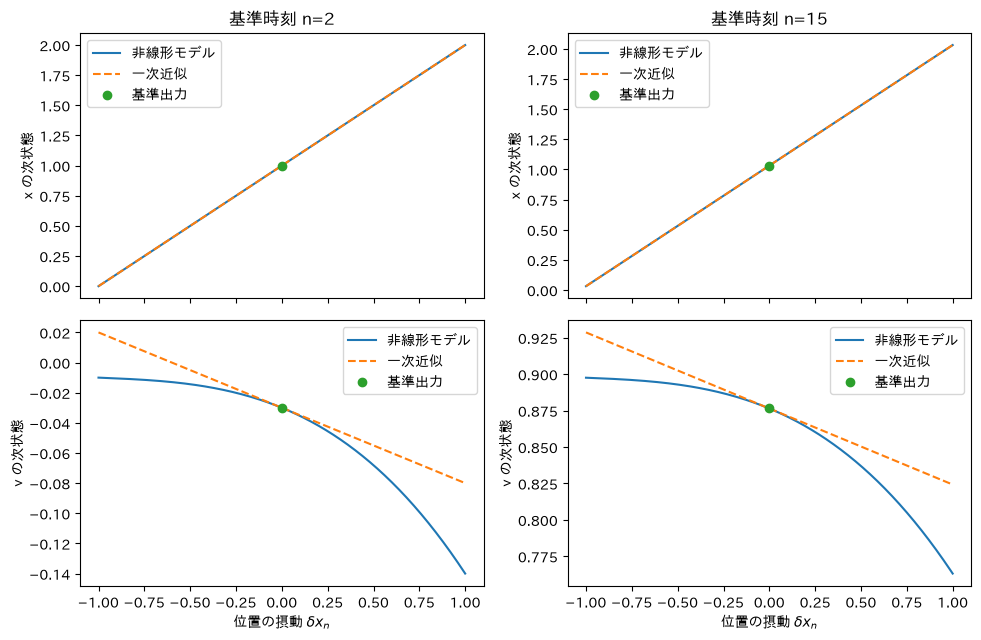

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib_fontja

dt = 0.01
m = 1.0
k = 0.5
k3 = 1.5

# 非線形バネの状態方程式
def f(x, v, u):
    return np.array([x + dt*v,
                     v + dt/m*(-k*x - k3*x**3 + u)])

# 状態方程式の状態に関するヤコビ行列
def A(x,v,u):
    return np.array([[1 , dt],
                     [-dt/m*(k + 3*k3*x**2), 1]])

# 状態方程式の入力に関するヤコビ行列
def B(x,v,u):
    return np.array([[0],
                     [dt/m]])
    
def main():
    
    # 基準軌道の初期化
    N = 20
    x_0 = 1.0
    v_0 = 0.0
    U = np.array([i for i in range(N)])
    X = np.zeros((N+1, 2))

    # 基準軌道
    X[0, :] = np.array([x_0, v_0])
    for i in range(1, N+1):
        x, v = f(X[i-1, 0], X[i-1, 1], U[i-1])
        X[i, :] = np.array([x, v])
    
    # 基準位置1
    idx1 = 2
    
    # 基準位置2
    idx2 = 15
    
    fig, ax = plt.subplots(2, 2, figsize=(10, 6.5), sharex=True)

    # xの摂動に対する次状態の変化を確認
    dx_values = np.linspace(-1.0, 1.0, 201)

    for col, idx in enumerate([idx1, idx2]):
        bar_X = X[idx]
        bar_u = U[idx]
        bar_next = f(bar_X[0], bar_X[1], bar_u)
        A_n = A(bar_X[0], bar_X[1], bar_u)

        true_next = np.array([
            f(bar_X[0] + dx, bar_X[1], bar_u)
            for dx in dx_values
        ])

        linear_next = np.array([
            bar_next + A_n @ np.array([dx, 0.0])
            for dx in dx_values
        ])

        for row, name in enumerate(["x", "v"]):
            ax[row, col].plot(
                dx_values, true_next[:, row], label="非線形モデル"
            )
            ax[row, col].plot(
                dx_values, linear_next[:, row], "--", label="一次近似"
            )
            ax[row, col].plot(
                0, bar_next[row], "o", label="基準出力"
            )
            ax[row, col].set_ylabel(f"{name} の次状態")
            ax[row, col].legend()

        ax[0, col].set_title(f"基準時刻 n={idx}")
        ax[1, col].set_xlabel(r"位置の摂動 $\delta x_n$")

    fig.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()


基準点を2点おき、そこでの非線形バネとそれを一次近似したモデルの出力を表示している。摂動は$\delta x_n$のみとし、この時の状態$X_n$の違いを示している。

図の1行目が位置$x$、2行目が速度$v$の非線形モデルと一次近似モデルの差を示している。図が示すように、速度$v$にのみ差が生じている。

摂動は $x_{n} + \delta x_n$のみ行っているので、これを非線形バネの状態方程式に適用すると次のようになる。($\bar{x}_n, \bar{v}_n, \bar{u}_n$)は基準点であり、そこから $\delta x_n$ を摂動させているため、$x_{n+1}$は線形となり、$v_{n+1}$は非線形となっていることが分かる。

$$
\begin{aligned}
X_{n+1} =
\begin{bmatrix} 
x_{n+1} \\
v_{n+1} 
\end{bmatrix} &=
\begin{bmatrix}
\bar{x}_n + \delta x_n + \Delta t \bar{v}_n \\
\bar{v}_n + \dfrac{\Delta t}{m}\left(\bar{u}_n - k (\bar{x}_n+\delta x_n)- k_3( \bar{x}_n + \delta x_n)^3 \right)
\end{bmatrix} \\
\end{aligned}
$$

次に一次近似モデルの式に適用すると、次のようになる。よって、位置も速度も線形となっていることが分かる。

$$
\begin{aligned}
X_{n+1}^{lin}  = 
\begin{bmatrix} 
x_{n+1}^{lin} \\
v_{n+1}^{lin} 
\end{bmatrix} &=
\bar{X}_{n+1} + 
\begin{bmatrix}
1 & \Delta t \\
- \dfrac{\Delta t}{m}\left( k + 3 k_3 \bar{x}_n^2 \right) & 1
\end{bmatrix}
\begin{bmatrix} \delta x_n \\ 0 \end{bmatrix}
+\begin{bmatrix}
0 \\
\dfrac{\Delta t}{m}
\end{bmatrix} 0 \\
&=
\begin{bmatrix} 
\bar{x}_n + \Delta t \bar{v}_n \\
\bar{v}_{n} + \dfrac{\Delta t}{m}\left(\bar{u}_n - k \bar{x}_n - k_3 \bar{x}_n^3 \right) 
\end{bmatrix} +
\begin{bmatrix}
\delta x_n \\
- \dfrac{\Delta t}{m}\left( k + 3 k_3 \bar{x}_n^2 \right) \delta x_n
\end{bmatrix}
\end{aligned}
$$  

以上より、非線形バネでは、速度のみが非線形と線形の差が生じることが分かる。また、$\delta v_{n}, \delta u_{n}$を摂動させても、もともとの$v_n,u_n$が非線形項ではないため一次近似モデルとの差はないといえる。


## 2. コスト関数の二次近似

iLQRで扱う総コストを、ステージコスト $\ell_n$ と終端コスト $\phi$ を用いて次のように表す。

$$
J(X,U)=\phi(X_N)+\sum_{n=0}^{N-1}\ell_n(X_n,u_n)
$$

非線形動力学モデルを線形化したときと同様に、基準点($\bar{X}_n, \bar{u}_n$)から少し離れた近傍点では、総コストが次のようになる。

$$
X_n = \bar{X}_n + \delta X_n , \quad u_n = \bar{u}_n + \delta u_n
$$

$$
J(\bar{\mathbf{X}} + \delta \mathbf{X},\bar{\mathbf{U}} + \delta \mathbf{U})=\phi(\bar{X}_N + \delta X_N)+\sum_{n=0}^{N-1}\ell_n(\bar{X}_n + \delta X_n,\bar{u}_n + \delta u_n)
$$

ステージコスト$\ell_n$と終端コスト$\phi$は[Step2](./step2.ipynb)ではそれぞれを2次形式で構成したが、コストはそれだけでなく、例えば以下のような様々な形が考えられる。以下では$z,\theta$はスカラーで$q,\mu$を重みとして表現している。

|コスト|使う場面|二次形式との違い|
|:---|:---|:---|
|$c(z)=q(z-z_{ref})^4$|目標からの大きな位置誤差に対して強いペナルティを与える|基準位置によって曲がり方が変わる|
|$c(\theta)=q[1-\cos(\theta - \theta_{ref})]$|角度の周期性を考慮する|角度差$2\pi$を誤差ゼロとして扱える|
|$c(z)=q/2[h(z) - y_{ref}]^4$|手先位置など、状態から計算した量$h(z)$を目標へ近づける|$h(z)$が非線形ならコストも一般に非2次|
|$c(z)=-\mu \log(z_{max} - z)$|上限$z < z_{max}$に近づくことに強いペナルティを与える|上限に近づくほどコストが急増する|

iLQRでは、基準軌道の周りに局所的な線形・二次(Linear Quadratic : LQ)問題を構成し、backward pass でその問題を解くことにより、入力修正則である $\delta u_n$ を以下のように求める。

$$
\delta u_n = k_n + K_n \delta X_n
$$

ここで、$k_n$は基準入力を修正するフィードフォワード修正項であり、$K_n \delta X_n$は基準状態からのズレに応じて基準入力を修正するフィードバック修正項である。

この局所LQ問題を構成するため、非線形動力学モデルを上記のように一次近似し、ステージコストと終端コストを二次近似する。

### ステージコスト $\ell_n$

$$
\boxed{
\begin{aligned}
\ell_n(\bar{X}_n + \delta X_n,\bar{u}_n + \delta u_n) \approx& \ell_n(\bar{X}_n, \bar{u}_n) \\
&+ \ell_{X}^T \delta X_n + \ell_{u}^T \delta u_n \\ 
&+ \frac{1}{2}\delta X_n^T \ \ell_{XX} \ \delta X_n + \delta u_n^T \ \ell_{uX} \ \delta X_n + \frac{1}{2} \delta u_n^T \ \ell_{uu} \ \delta u_n  
\end{aligned}
}
$$

$$
\boxed{
\begin{array}{c}
\ell_{X} = \left. \dfrac{\partial \ell}{\partial X} \right|_{(\bar{X}_n, \bar{u}_n)} , \quad \ell_{u} = \left. \dfrac{\partial \ell}{\partial u} \right|_{(\bar{X}_n, \bar{u}_n)} \\
\ell_{XX} =  \left. \dfrac{\partial^2 \ell}{\partial X^2} \right|_{(\bar{X}_n, \bar{u}_n)} , \quad \ell_{uX} =  \left. \dfrac{\partial}{\partial X}\left(\dfrac{\partial \ell}{\partial u }\right) \right|_{(\bar{X}_n, \bar{u}_n)}, \quad \ell_{uu} =  \left. \dfrac{\partial^2 \ell}{\partial u^2} \right|_{(\bar{X}_n, \bar{u}_n)}
\end{array}
}
$$

$\ell_n$はスカラになるように構成される。状態$X$と入力$u$は多変数のベクトルも扱うことができるため、これで偏微分を行うと、$\ell_{X}, \ell_{u}$の1階偏微分はベクトル形式となり、$\ell_{XX}, \ell_{uu}$はHessian、$\ell_{uX}$は混合二階微分行列になる。よって2次近似は全体的にはスカラーの式である。

具体的に考えるため、$\ell_n(X, u)$を次のように設定する。

$$
\ell_n(X, u) = q_x[1 - \cos(x - x_{ref})] + \frac{1}{2} q_v v^2 + r u^4, \quad X_n = \begin{bmatrix} x \\ v \end{bmatrix}
$$

これを偏微分していくと、次のようになる。

$$
\begin{aligned}
\frac{\partial \ell}{\partial X} &= \begin{bmatrix} \dfrac{\partial \ell}{\partial x} \\[8pt] \dfrac{\partial \ell}{\partial v} \end{bmatrix} = \begin{bmatrix}
q_x \sin(x - x_{ref}) \\ q_v v
\end{bmatrix} \\
\frac{\partial \ell}{\partial u} &= 4 r u^3 \\
\frac{\partial^2 \ell}{\partial X^2} &= \begin{bmatrix}
\dfrac{\partial^2 \ell}{\partial x^2} & \dfrac{\partial^2 \ell}{\partial x \partial v} \\[8pt]
\dfrac{\partial^2 \ell}{\partial v \partial x} & \dfrac{\partial^2 \ell}{\partial v^2} \\[8pt]
\end{bmatrix} = \begin{bmatrix}
q_x \cos(x-x_{ref}) & 0 \\
0 & q_v
\end{bmatrix} \\
\frac{\partial}{\partial X} \left(\frac{\partial \ell}{\partial u} \right) &= \begin{bmatrix}
\dfrac{\partial^2 \ell}{\partial u \partial x} & \dfrac{\partial^2 \ell}{\partial u \partial v} \\[8pt]
\end{bmatrix} = \begin{bmatrix}
0 & 0
\end{bmatrix} \\
\frac{\partial^2 \ell}{\partial u^2} &=  12 r u^2
\end{aligned}
$$

$\dfrac{\partial}{\partial X} \left(\dfrac{\partial \ell}{\partial u} \right)$が横ベクトルになる理由は、<br>
$\delta u_n^T \ell_{uX} \delta X_n$がスカラーとなるため $\delta u_n^T \in \mathbf{R}^{1 \times n_u}, \ell_{uX} \in \mathbf{R}^{n_u \times n_x}, \delta X_n \in \mathbf{R}^{n_x \times 1}$ である必要からである。

よって、ステージコストの基準点近傍点は以下のようにスカラーとして構成される。

$$
\begin{aligned}
\ell_n(\bar{X}_n + \delta X_n, \bar{u}_n + \delta u_n) \approx& q_x[1-\cos(\bar{x}_n - x_{ref})] + \frac{1}{2}q_v \bar{v}_n^2 + r \bar{u}_n^4 \\
& + q_x \sin(\bar{x}_n - x_{ref}) \delta x_n + q_v \bar{v}_n \delta v_n + 4 r \bar{u}_n^3 \delta u_n \\
& + \frac{1}{2} q_x \cos(\bar{x}_n - x_{ref}) \delta x_n^2 + \frac{1}{2} q_v \delta v_n^2 + 6 r \bar{u}_n^2 \delta u_n^2
\end{aligned} 
$$

この式では、基準状態$\bar{X}_n$と基準入力$\bar{u}_n$に対し、仮の修正量$\delta X_n , \delta u_n$ を与えたとき、ステージコストがどのように変化するかをTaylor展開の2次の項までの式で近似している。

3行で構成しているが、それぞれの意味は次のようになる。

- 1行目 : 現在の基準点($\bar{X}_n, \bar{u}_n$)におけるステージコスト
- 2行目 : 基準点から状態と入力を少し動かしたときの、コストの変化方向と変化量を表す一次項
- 3行目 : 基準点から状態と入力を少し動かしたときの、コストの曲がり方を表す二次項

一次項は、基準点におけるコストの勾配と修正量の積である。

$$
\ell_X^T \delta X_n + \ell_u^T \delta u_n
$$

この値が負になる方向へ$\delta X_n \delta u_n$を選べば、局所近似上ではコストが減少する。したがって1階偏微分の$\ell_X, \ell_u$は、基準状態と基準入力をどちらの方向へ修正すればよいかを表す。

二次項は、基準点におけるコストの曲率を表す。

$$
\frac{1}{2} \delta X_n^T \ \ell_{XX} \ \delta X_n + \delta u_n^T \ \ell_{uX} \ \delta X_n + \frac{1}{2} \delta u_n^T \ \ell_{uu} \ \delta u_n
$$


これは、基準点から動いたときにコストの傾きがどのように変化するかを表す。すなわちコストが谷型、山型、または方向によって異なる形(鞍)のいずれかであることを示す。

ステージコストの一次項と二次項には、線形化動力学モデルは直接含まれない。backward passでは、ステージコストの二次近似と線形化動力学モデルを次時刻の価値関数を介して組み合わせ、将来を含むコストを小さくする入力修正則を求める。

### 終端コスト $\phi$

終端コストも基準点近傍でTaylor展開を行い2次項までを用いて構成すると以下の近似式となる。

$$
\boxed{
\phi(\bar{X}_N + \delta X_N) \approx \phi(\bar{X}_N) + \phi_X^T \ \delta X_N + \frac{1}{2} \delta X_N^T \ \phi_{XX} \ \delta X_N
}
$$

$$
\boxed{
\phi_X = \left. \dfrac{\partial \phi}{\partial X} \right|_{(\bar{X}_N)}, \quad \phi_{XX} = \left. \dfrac{\partial^2 \phi}{\partial X^2} \right|_{(\bar{X}_N)}
}
$$ 

この式もステージコストと同様に次を意味する。

- 1項目 : 最終基準点($\bar{X}_N$)における終端コスト
- 2項目 : 最終基準点から状態を少し動かしたときの、コストの変化方向と変化量を表す一次項
- 3項目 : 最終基準点から状態を少し動かしたときの、コストの曲がり方を表す二次項


終端時刻 $N$ ではそれ以降のステージコストが存在しないため、終端コストを価値関数を用いて終端価値関数$V_N$と置く。

$$
V_N(X_N) = \phi(X_N)
$$

したがって、backward pass の初期値は

$$
V_{X,N} = \phi_X, \quad V_{XX, N} = \phi_{XX}
$$

となる。backward pass では、この終端価値関数から時刻 $N-1, N-2, \cdots , 0$ へ逆向きに将来のコストを伝える。

## 3. Q関数について


### 価値関数

ここでiLQRの価値関数$V_n(X_n)$について説明する。

まず、現在の時刻$n$から終端$N$までのコスト$J_n$を次のようにステージコストと終端コストで定義する。

$$
J_n(X_n, U_n) = \phi(X_N) + \sum_{i=n}^{N-1} \ell_i(X_i, u_i)
$$

$U_n$は時刻$n$から終端直前$N-1$まで入力列で以下である。

$$
U_n = [u_n, u_{n+1}, \cdots , u_{N-1}]
$$

また、状態$X_i$は以下のように非線形動力学モデルの離散時間状態方程式に従い計算される。

$$
X_{i+1} = f(X_i, u_i)
$$

価値関数は時刻$n$の状態$X_n$を固定したときコスト$J_n$を用いて以下で定義される。

$$
V_n(X_n) = \underset{U_n}{\min} J_n(X_n, U_n) =\underset{U_n}{\min} \left[\phi(X_N) + \sum_{i=n}^{N-1} \ell_i (X_i, u_i) \right]
$$

価値関数$V_n(X_n)$は、現在の状態が$X_n$であるとき、時刻$n$から終端$N$までの入力列を最適に選んだ場合に得られる最小コスト、を意味している。このとき、入力列$U_n$により、状態軌道は次のように生成される。

$$
\begin{aligned}
X_{n+1} =& f(X_n, u_n) \\
X_{n+2} =& f(X_{n+1}, u_{n+1}) \\
& \vdots \\
X_{N} =& f(X_{N-1}, u_{N-1})
\end{aligned}
$$

$U_n$により計算された状態軌道によりコストが$J_n(X_n, U_n)$のように計算される。よって、状態$X_n$を起点として、入力列$U_n$によりコストが決まる。価値関数は状態$X_n$を起点として入力列$U_n$を$J_n(X_n, U_n)$が最小になるように選んだ時、非線形動力学モデルに従って生成される状態軌道に対する最小コストである。

### Q関数

Q関数は時刻$n$で発生するステージコストと、非線形動力学モデルを介した次時刻以降の価値関数を次のように結びつける。

$$
Q_n(X_n, u_n) = \ell_n(X_n, u_n) + V_{n+1}(f(X_n, u_n))
$$

よって、それぞれの項は次を意味する。

- $\ell_n(X_n, u_n)$ : 時刻$n$で状態$X_n$と入力$u_n$を選んだ時、直ちに発生するステージコスト
- $V_{n+1}(f(X_n, u_n))$ : 入力$u_n$により状態$X_n$が次の状態$X_{n+1} = f(X_n ,u_n)$へ進んだ後、時刻$n+1$から終端までをコストが最小となる入力列によって求まった最小コスト

終端時刻$N$では、それ以降のステージコストが存在しないため、以下となる。

$$
V_N(X_N) = \phi(X_N)
$$

Q関数と価値関数は以下の関係である。

$$
V_n(X_n) = \underset{u_n}{\min} Q_n(X_n, u_n) = \underset{u_n}{\min} \left[ \ell_n(X_n, u_n) + V_{n+1}(f(X_n, u_n)) \right]
$$

Q関数 $Q_n(X_n, u_n)$ では、現在入力$u_n$は引数として与えられており、また$u_n$について最小化された値ではない。一方、価値関数$V_n(X_n)$は、Q関数を現在入力$u_n$について最小化した値として定義される。

Q関数による定義では、将来のコストを表す$V_{n+1}$は非線形動力学モデル$f$による関係となっている。そのため、以下の局所一次近似式とコストの二次近似による関係を結びつけていない。

- 非線形動力学モデルの局所一次近似式

$$
\delta X_{n+1} \approx A_n \delta X_n + B_n \delta u_n
$$

- ステージコストと終端コストの二次近似式

$$
\begin{aligned}
\ell_n(\bar{X}_n + \delta X_n,\bar{u}_n + \delta u_n) \approx& \ell_n(\bar{X}_n, \bar{u}_n) \\
&+ \ell_{X}^T \delta X_n + \ell_{u}^T \delta u_n \\ 
&+ \frac{1}{2}\delta X_n^T \ \ell_{XX} \ \delta X_n + \delta u_n^T \ \ell_{uX} \ \delta X_n + \frac{1}{2} \delta u_n^T \ \ell_{uu} \ \delta u_n  
\end{aligned}
$$

$$
\phi(\bar{X}_N + \delta X_N) \approx \phi(\bar{X}_N) + \phi_X^T \ \delta X_N + \frac{1}{2} \delta X_N^T \ \phi_{XX} \ \delta X_N
$$

そこで、Q関数を基準状態・基準入力周りで二次近似し、$\delta X_{n+1}$と$\ell_n(\bar{X}_n + \delta X_n,\bar{u}_n + \delta u_n), \phi(\bar{X}_N + \delta X_N)$の関係性をQ関数に導入する。



## 4. Q関数の二次近似

下記の$Q$関数は、非線形動力学モデル$f$と、その動力学に伴う将来の最小コストを表す価値関数$V_{n+1}$が含まれている。そのため、Q関数だけでは、まだ線形・二次問題(LQ問題)になっていない。

$$
Q_n(X_n, u_n) = \ell_n(X_n, u_n) + V_{n+1}(X_{n+1}) \\
X_{n+1} = f(X_n, u_n)
$$

そこで、基準軌道の周りで一次近似した線形動力学モデルと、二次近似したステージコストと次時刻の価値関数をQ関数へ代入して整理することで、Q関数を状態摂動$\delta X_n$と入力摂動$\delta u_n$に関する二次式として表す。

これにより、元の非線形最適化問題を、基準軌道の近傍で有効な局所的なLQ問題へ置き換える。

#### 4.1 次の時刻の価値関数を二次近似する

ステージコストの二次近似はすでに以下のように得られている。

$$
\begin{aligned}
\ell_n(\bar{X}_n + \delta X_n,\bar{u}_n + \delta u_n) \approx& \ell_n(\bar{X}_n, \bar{u}_n) \\
&+ \ell_{X}^T \delta X_n + \ell_{u}^T \delta u_n \\ 
&+ \frac{1}{2}\delta X_n^T \ \ell_{XX} \ \delta X_n + \delta u_n^T \ \ell_{uX} \ \delta X_n + \frac{1}{2} \delta u_n^T \ \ell_{uu} \ \delta u_n  
\end{aligned}
$$

価値関数$V_{n+1}(X_{n+1})$を基準状態$\bar{X}_{n+1}$の周りでTaylor展開し、二次近似式を以下のように構成する。

$$
V_{n+1}(\bar{X}_{n+1} + \delta X_{n+1}) \approx \bar{V}_{n+1} + V_{X, n+1}^T \delta X_{n+1} + \frac{1}{2} \delta X_{n+1}^T \ V_{XX, n+1} \ \delta X_{n+1}
$$

ここで、

$$
\bar{V}_{n+1} = V_{n+1}(\bar{X}_{n+1})
$$

終端時刻では、価値関数は以下となる。

$$
V_{N}(\bar{X}_{N} + \delta X_{N}) \approx \bar{V}_{N} + V_{X, N}^T \delta X_{N} + \frac{1}{2} \delta X_{N}^T \ V_{XX, N} \ \delta X_{N}
$$

これは下記の終端コストの2次近似と同じであるため、

$$
\phi(\bar{X}_N + \delta X_N) \approx \phi(\bar{X}_N) + \phi_X^T \ \delta X_N + \frac{1}{2} \delta X_N^T \ \phi_{XX} \ \delta X_N
$$

価値関数を対応させると以下となる。

$$
V_{N} = \phi , \quad V_{X,N} = \phi_X, \quad V_{XX, N} = \phi_{XX}
$$

#### 4.2 線形化動力学摂動モデルの代入

非線形動力学モデルを局所一次近似した線形動力学摂動モデルは以下であった。

$$
\delta X_{n+1} \approx A_n \delta X_n + B_n \delta u_n
$$

これを価値関数$V_{n+1}$の近似式に代入する。

$$
\begin{aligned}
V_{n+1}(\bar{X}_{n+1} + \delta X_{n+1}) \approx& \bar{V}_{n+1} + V_{X, n+1}^T \left( A_n \delta X_n + B_n \delta u_n \right) \\ & + \frac{1}{2} \left(A_n \delta X_n + B_n \delta u_n \right)^T \ V_{XX, n+1} \ \left(A_n \delta X_n + B_n \delta u_n \right)
\end{aligned}
$$

これを展開してまとめると、次のようになる。

$$
\begin{aligned}
V_{n+1}(\bar{X}_{n+1} + \delta X_{n+1}) \approx& \bar{V}_{n+1} \\
& + V_{X, n+1}^T  A_n \delta X_n + V_{X, n+1}^T B_n \delta u_n  \\
& + \frac{1}{2}   \delta X_n^T A_n^T V_{XX, n+1}  A_n \delta X_n \\
& + \delta u_n^T  B_n^T V_{XX, n+1}  A_n \delta X_n \\
& + \frac{1}{2} \delta u_n^T B_n^T  V_{XX, n+1} B_n \delta u_n 
\end{aligned}
$$

$\delta u_n^T  B_n^T V_{XX, n+1}  A_n \delta X_n$はHessianで$V_{XX,n+1}$が対称行列であるためこのようにまとめることが出来る。

#### 4.3 ステージコストとの足し合わせ

Q関数の近傍点の式に上記の$\ell_n$と$V_{n+1}$を代入して足し合わせる。

$$
\begin{aligned}
Q_n(\bar{X}_n + \delta X_n, \bar{u}_n+ \delta u_n) =& \ell_n(\bar{X}_n + \delta X_n, \bar{u}_n+ \delta u_n) + V_{n+1}(\bar{X}_{n+1} + \delta X_{n+1}) \\
\approx & \bar{Q}_n + Q_X^T \delta X_n + Q_u^T \delta u_n \\
& + \frac{1}{2} \delta X_n^T Q_{XX} \delta X_n + \delta u_n^T Q_{uX} \delta X_n + \frac{1}{2} \delta u_n^T Q_{uu} \delta u_n
\end{aligned}
$$

各係数がそれぞれ以下の構成となっている。

$$
\begin{aligned}
\bar{Q}_n =& \ell_n(\bar{X}_n, \bar{u}_n) + \bar{V}_{n+1} \\
Q_X =& \ell_X + A_n^T V_{X,n+1} \\
Q_u =& \ell_u + B_n^T V_{X,n+1} \\
Q_{XX} =& \ell_{XX} + A_n^T V_{XX, n+1} A_n \\
Q_{uX} =& \ell_{uX} + B_n^T V_{XX, n+1} A_n \\
Q_{uu} =& \ell_{uu} + B_n^T V_{XX, n+1} B_n
\end{aligned}
$$

係数の意味はそれぞれ以下である。

- $\bar{Q}_n$ : 現在の基準軌道におけるコストと将来発生する最小コスト
- $Q_X$ : 状態を変化させたとき、現在から終端までのコストがどちらに変化するか
- $Q_u$ : 入力を変化させたとき、現在から終端までのコストがどちらに変化するか
- $Q_{XX}$ : 状態に関するQ関数の曲率
- $Q_{uX}$ : 状態と入力の変化がQ関数へ与える相互作用
- $Q_{uu}$ : 入力に関するQ関数の曲率

これらの係数は時刻$n$のステージコストと時刻$n+1$以降の価値関数の組み合わせになっていることが重要であり、例えば

$$
Q_X = \ell_X + A_n^T V_{X,n+1}
$$

は

- $\ell_X$ : 状態変更が、現在のステージコストに与える影響
- $A_n^T V_{X,n+1}$ : 状態変更が、動力学を介して将来コストに与える影響

を足したものになっている。これで、ステージコスト、一次近似線形化摂動モデル、将来の価値関数がQ関数により一つの関係になった。

また、コストが次のように$\bar{Q}_n$の基準点からコストと変化を表す一次項と二次項に分かれている。

$$
Q_n \approx \underset{\text{基準点でのコスト}}{\bar{Q}_n} + \underset{コストが変化する方向}{\text{一次項}} + \underset{コストの曲率}{\text{二次項}}
$$

$\bar{Q}_n$は基準点における現在ステージコストと次時刻以降の最小コストである。

$$
\bar{Q}_n = \ell_n(\bar{X}_n, \bar{u}_n) + \bar{V}_{n+1}
$$

$\delta X_{n}=\delta u_{n}=0$のとき、非線形動力学モデルと一次近似した線形動力学モデルは以下で一致する。

$$
\begin{aligned}
X_{n+1}^{lin} &= \bar{X}_{n+1} + A_n \cdot 0 + B_n \cdot 0 \\
&= \bar{X}_{n+1} \\
&= f(\bar{X}_n, \bar{u}_n)
\end{aligned}
$$

また、局所二次Q関数は基準点において元のQ関数と同じ$\bar{Q}_n$を持つ。

したがって、基準点でのコスト水準は$\bar{Q}_n$として保持し、基準点からの状態と入力の変化は、線形化動力学とQ関数の一次項・二次項によって近似する。

すなわち、iLQRでは基準値を元の非線形モデルに基づいて保持し、基準点からの変化分を局所的な線形・二次モデルによって計算する。